Tutorial

[YT link](https://youtu.be/IU5fuoYBTAM?si=4UQuKPijhnQcMp27)



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [ ]:
df = pd.read_csv('/content/homeprices_banglore.csv')
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [ ]:
from sklearn import preprocessing

sx = preprocessing.MinMaxScaler()
sy = preprocessing.MinMaxScaler()

scaled_x = sx.fit_transform(df.drop('price',axis='columns'))
scaled_y = sy.fit_transform(df.price.values.reshape(df.shape[0],1))

In [ ]:
scaled_x

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [ ]:
scaled_y

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

In [ ]:
w = np.ones(shape=scaled_x.shape[1])
w.shape

(2,)

In [ ]:
def barch_gradient_descent(x,y_true,epochs,learning_rate=0.01):
  num_of_features = x.shape[1]
  w = np.ones(shape=(num_of_features))
  b = 0
  total_samples = x.shape[0]

  cost_list = []
  epoch_list = []

  for i in range(epochs):
    y_pred = np.dot(x,w) + b
    w_grad = (-2/total_samples)*np.dot(x.T,(y_true - y_pred))
    b_grad = (-2/total_samples)*np.sum((y_true - y_pred))
    w = w - learning_rate*w_grad
    b = b - learning_rate*b_grad
    cost = np.mean(np.square(y_true - y_pred))
    if(i%10==0):
      cost_list.append(cost)
      epoch_list.append(i)

  return w,b,cost,cost_list,epoch_list


w,b,cost,cost_list,epoch_list = barch_gradient_descent(scaled_x,scaled_y.reshape(scaled_y.shape[0]),500)
w,b,cost

(array([0.70712464, 0.67456527]),
 np.float64(-0.23034857438407427),
 np.float64(0.0068641890429808105))

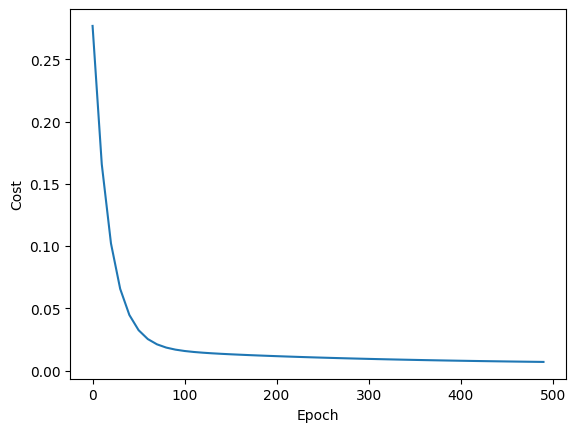

In [ ]:
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.plot(epoch_list,cost_list)

In [ ]:
def predict(area,bedroom,w,b):
  scaled_X = sx.transform([[area,bedroom]])[0]
  price = w[0]*scaled_X[0] + w[1]*scaled_X[1] + b
  return sy.inverse_transform([[price]])[0][0]


predict(2600,3,w,b)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(105.68826628865837)

In [ ]:
predict(1000,2,w,b)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(30.253094462442355)

In [ ]:
from numpy._core.fromnumeric import reshape
def stochastic_gradient_descent(x,y_true,epochs,learning_rate=0.01):
  numbers_of_features = x.shape[1]
  total_samples = x.shape[0]
  w = np.ones(shape=(numbers_of_features))
  b = 0

  cost_list = []
  epoch_list = []

  for epoch in range(epochs):
    random_idx = random.randint(0,total_samples-1)
    sample_x = x[random_idx]
    sample_y = y_true[random_idx]
    y_pred = np.dot(sample_x,w) + b
    w_grad = (-2/total_samples)*np.dot(sample_x.T,(sample_y - y_pred))
    b_grad = (-2/total_samples)*np.sum((sample_y - y_pred))
    w = w - learning_rate*w_grad
    b = b - learning_rate*b_grad
    cost = np.mean(np.square(sample_y - y_pred))
    if(epoch%10==0):
      cost_list.append(cost)
      epoch_list.append(epoch)
  return w,b,cost,cost_list,epoch_list


w,b,cost,cost_list,epoch_list = stochastic_gradient_descent(scaled_x,scaled_y.reshape(scaled_y.shape[0]),epochs=500)
w,b,cost

(array([0.91867615, 0.89963014]),
 np.float64(-0.1676500277153952),
 np.float64(0.1508370287126822))

In [ ]:
def predict(area,bedroom,w,b):
  scaled_X = sx.transform([[area,bedroom]]) # scaled_X is (1,2) array, e.g., [[val1, val2]]
  # Perform dot product: (1,2) dot (2,1) results in a (1,1) array
  predicted_scaled_price_array = np.dot(scaled_X, w) + b
  # Extract the scalar value from the (1,1) array
  predicted_scaled_price = predicted_scaled_price_array[0][0]
  return sy.inverse_transform([[predicted_scaled_price]])[0][0]

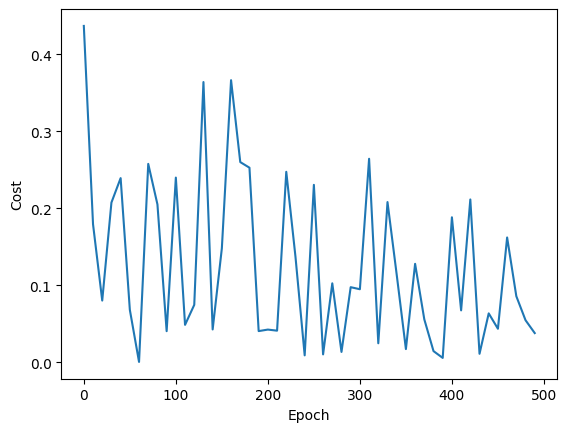

In [ ]:
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.plot(epoch_list,cost_list)

In [ ]:
np.random.permutation(20)

array([11,  5, 17,  7,  1,  0, 14,  8,  2, 16, 12,  3,  6, 15,  4, 10, 13,
        9, 19, 18])

In [ ]:
def mini_batch_gradient_descent(x,y_true,epochs,batch_size,learning_rate=0.01):
  num_of_features = x.shape[1]
  total = x.shape[0]
  w = np.ones(shape=(num_of_features,1))
  b = 0
  cost = 0
  cost_list = []
  epoch_list = []
  if(batch_size>total):
    batch_size = total
  num_of_batches = int(total/batch_size)
  for epoch in range(epochs):
    idx = np.random.permutation(total)

    X_temp = x[idx]
    Y_temp = y_true[idx]

    for i in range(0,total,batch_size):
      xx = X_temp[i:i+batch_size]
      yy = Y_temp[i:i+batch_size]
      y_pred = np.dot(xx,w) + b
      w_grad = (-2/batch_size)*np.dot(xx.T,(yy - y_pred))
      b_grad = (-2/batch_size)*np.sum((yy - y_pred))

      w = w - learning_rate*w_grad
      b = b - learning_rate*b_grad

      cost = np.mean(np.square(yy - y_pred))
    cost_list.append(cost)
    epoch_list.append(epoch)
  return w,b,cost,cost_list,epoch_list

w,b,cost,cost_list,epoch_list = mini_batch_gradient_descent(scaled_x,scaled_y,epochs=500,batch_size=20)
w,b,cost

(array([[0.70712464],
        [0.67456527]]),
 np.float64(-0.23034857438407422),
 np.float64(0.006864189042980811))

In [ ]:
def prediction(area,bedroom,w,b):
  scaled_X = sx.transform([[area,bedroom]])
  predicted_scaled_price_array = np.dot(scaled_X, w) + b
  predicted_scaled_price = predicted_scaled_price_array[0][0]
  return sy.inverse_transform([[predicted_scaled_price]])[0][0]

prediction(2600,3,w,b)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(105.68826628865838)

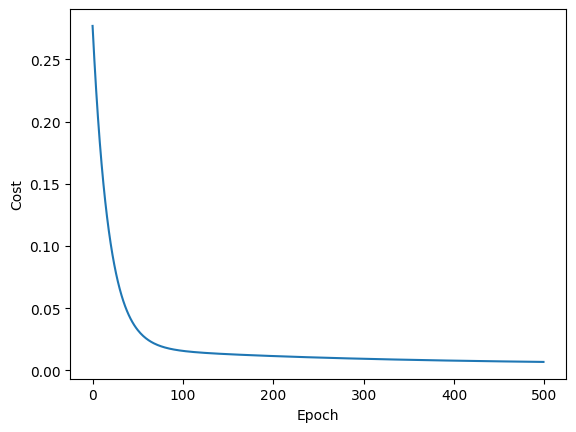

In [ ]:
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.plot(epoch_list,cost_list)